In [41]:
# !pip install legacy-cgi

In [42]:
import os
import subprocess
from pathlib import Path
from PIL import Image
## dataset and Visualization
import numpy as np
import pandas as np
import matplotlib.pyplot as plt
import opendatasets as od
import random
## Torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchmetrics import Accuracy
##Torchvision
from torchvision import datasets,transforms

In [43]:
repo_name = "machine-learning-projects"
repo_path = f'/content/{repo_name}'
repo_url = f"https://github.com/Ebenezeragyemang10/{repo_name}"
sub_working_dir = "chest-x-ray-classification-cnn"


if not os.path.isdir(repo_path):
  print("cloning")
  subprocess.run(["git", "clone", repo_url])

else:
  print("directory already exist....")


target_dir = os.path.join(repo_path, sub_working_dir) if sub_working_dir else repo_path
os.chdir(target_dir)

directory already exist....


In [44]:
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data",

)


Skipping, found downloaded files in "./chest-xray-pneumonia" (use force=True to force download)


In [45]:
dataset_dir = f'{target_dir}/chest-xray-pneumonia/chest_xray'
train_dir = f'{dataset_dir}/train'
test_dir = f'{dataset_dir}/test'
valid_dir = f'{dataset_dir}/val'


In [46]:
## Visualize the data

In [47]:
print(f"Total training normal xrays: {len(os.listdir(train_dir + "/NORMAL"))}")
print(f"Total training Pneumonia xrays: {len(os.listdir(train_dir + "/PNEUMONIA"))}")
print(f"Total testing normal xrays: {len(os.listdir(test_dir + "/NORMAL"))}")
print(f"Total testing Pneumonia xrays: {len(os.listdir(test_dir + "/PNEUMONIA"))}")

Total training normal xrays: 1341
Total training Pneumonia xrays: 3875
Total testing normal xrays: 234
Total testing Pneumonia xrays: 390


In [48]:
normal_train = os.listdir(f'{train_dir}/NORMAL')
pneumonia_train = os.listdir(f'{train_dir}/PNEUMONIA')
normal_test  = os.listdir(f'{test_dir}/NORMAL')
pneumonia_test = os.listdir(f'{test_dir}/PNEUMONIA')


In [49]:
train_count = [
    len(normal_train),
    len(pneumonia_train)
]
print(train_count)
classes = [
    "Normal",
    "Pneumonia"
]

[1341, 3875]


Text(0, 0.5, 'xray class Count')

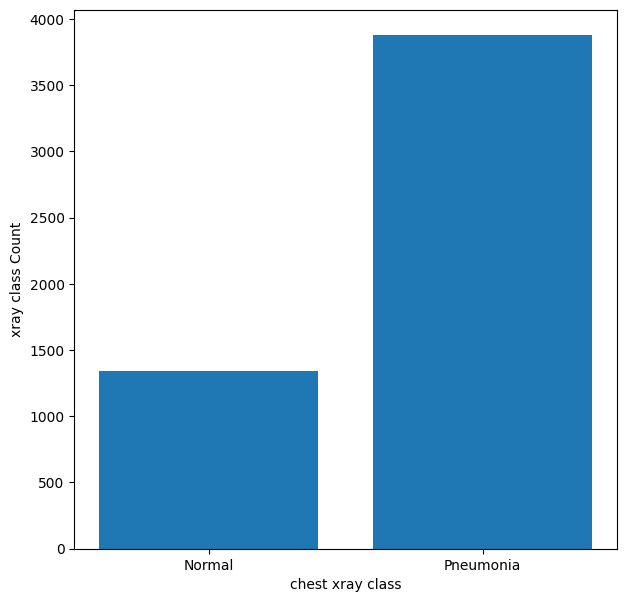

In [50]:
plt.figure(figsize=(7, 7))
plt.bar(classes,train_count)
plt.xlabel("chest xray class")
plt.ylabel("xray class Count")

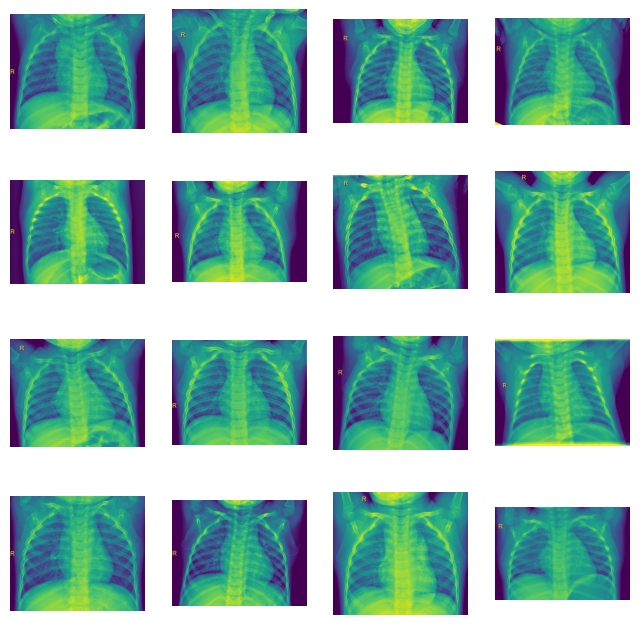

In [51]:
#visualizing normal train images
nrows, ncols = 4, 4
plt.figure(figsize=(8, 8))
for i in range(1, nrows*ncols+1):
  random_image_name  = random.choice(normal_train)
  random_image_path = f"{train_dir}/NORMAL/{random_image_name}"
  image= Image.open(random_image_path)
  plt.subplot(nrows, ncols, i)
  plt.imshow(image)
  plt.axis("OFF")


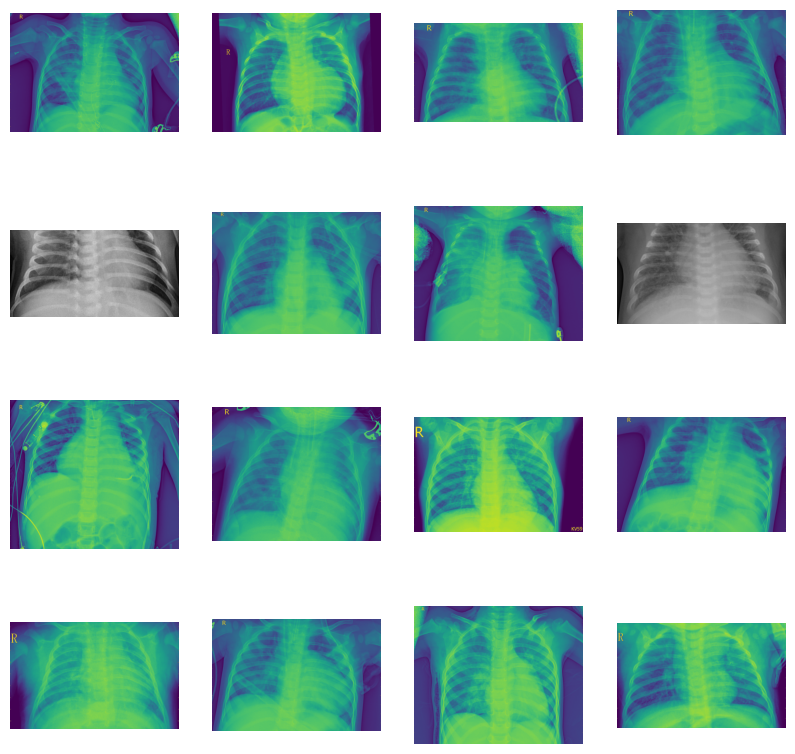

In [52]:
## Visualizing Pneumonia Xray Images
num_cols = 4
num_rows = 4
plt.figure(figsize=(10, 10))
for i in range(1, num_cols*num_rows+1):
  random_image = random.choice(pneumonia_train)
  random_image_name =  f"{train_dir}/PNEUMONIA/{random_image}"
  image = Image.open(random_image_name)
  plt.subplot(num_rows, num_cols, i)
  plt.imshow(image)
  plt.axis("OFF")






image path: /content/machine-learning-projects/chest-x-ray-classification-cnn/chest-xray-pneumonia/chest_xray/train/NORMAL/IM-0698-0001.jpeg
image format: JPEG
image size: (1952, 1777)


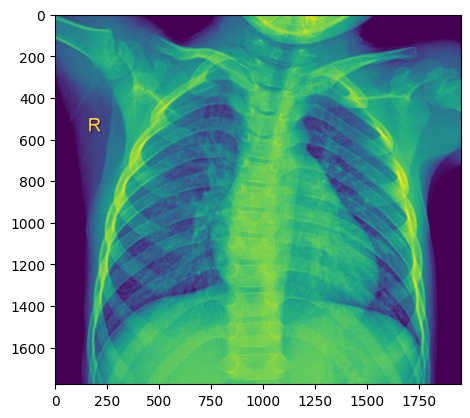

In [53]:
random_normal_xray = random.choice(normal_train)
image_path = f'{train_dir}/NORMAL/{random_normal_xray}'
img = Image.open(image_path)
plt.imshow(img)
print("image path:", image_path)
print("image format:", img.format)
print("image size:", img.size)

In [54]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
    ]
)

In [55]:

BATCH_SIZE = 32
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

In [56]:
print(f'classes : { train_dataset.classes}')
print(f'classes tndices: { train_dataset.class_to_idx}')

classes : ['NORMAL', 'PNEUMONIA']
classes tndices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [57]:
### Define Model

class XrayNet(nn.Module):
  def __init__(self, NUM_CLASSES=2):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding="same"),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same"),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3,padding="same"),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2))

    self.global_pool = nn.AdaptiveAvgPool2d((1, 1)),
    self.classifier=(
        nn.Dropout(p=0.4),
        nn.Linear(in_features=256, out_features=128),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(in_features=128, out_features=NUM_CLASSES),
    )

  def forward(self, x):
    x= self.features(x)
    x = self.global_pool(x)
    x =torch.flatten(x, 1)
    x =self.classifier(x)
    return x


In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = XrayNet(NUM_CLASSES=2).to(device=device)
criterion= nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)
metrics = Accuracy(task="binary")


In [61]:
def evaluate_model(model, dataloader, metrics, criterion, device):
  model.eval()
  metrics.reset()
  total_loss = 0.0

  with torch.inference_mode():
    for x_batch, y_batch in dataloader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      y_logits= model(x_batch)
      y_prob = torch.sigmoid(y_logits)
      metrics.update(y_logits, y_batch)
      loss = criterion(y_logits, y_batch)
      total_loss += loss.item()
  average_loss = total_loss/ len(dataloader)
  average_metrics = metrics.compute().item()
  return average_loss, average_metrics

def train_model(train_loader, test_loader, model, criterion, optimizer, metrics, epochs, device):


  for epoch in range(epochs):
    train_loss = 0.0
    metrics.reset()
    model.train()
    for x_batch, y_batch in train_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      y_logits = model(x_batch)
      y_prob = torch.sigmoid(y_logits)
      loss = criterion(y_logits, y_batch)
      metrics.update(y_prob, y_batch)
      train_loss += loss.item()

      loss.backward()
      optimizer.zero_grad()
      optimizer.step()











